# Mid-season forecast of the 2015/2016 Premier League

This notebook uses the baseline model from `src/model.py` to forecast the second half of the 2015/2016 Premier League season.

The model is deliberately simple: each team has one latent strength, there is one global home advantage, and home/away goals are Poisson distributed. We train on all EPL matches before 2015/2016 plus the first half of 2015/2016, then forecast stages 20-38.

All 20 teams are included. Bournemouth and Watford have no previous EPL observations before 2015/2016, but they are included because the first-half training data gives the model observed matches for both teams before the second-half forecast window.


## 1. Setup

The path logic below works whether the notebook is launched from the project root or from the `notebooks` folder. The dependency check is intentionally explicit because the model section needs PyTorch and Pyro.


In [13]:
from pathlib import Path
import importlib.util
import sys


def find_project_root(start_path):
    start_path = Path(start_path).resolve()
    candidates = [start_path, *start_path.parents]
    for candidate in candidates:
        if (candidate / "data" / "epl_matches.csv").exists() and (candidate / "src" / "model.py").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/epl_matches.csv and src/model.py")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
SRC_DIR = PROJECT_ROOT / "src"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "torch": "torch",
    "pyro": "pyro-ppl",
}

missing_packages = [
    install_name
    for import_name, install_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    raise ImportError(
        "Missing required packages for this notebook section: "
        + ", ".join(missing_packages)
        + ". Install them in the active notebook kernel environment."
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import pyro
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.optim import Adam

from model import FootballModel

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

DATA_PATH = DATA_DIR / "epl_matches.csv"
DATA_PATH


WindowsPath('C:/Users/Madsl/Dropbox/DTU/Kand/3.Semester/MBML/Project_MBML/data/epl_matches.csv')

## 2. Load data and create the mid-season split

Training uses all seasons before 2015/2016 plus stages 1-19 of 2015/2016. The forecast target is stages 20-38 of 2015/2016. No teams are excluded.


In [14]:
TEST_SEASON = "2015/2016"
FIRST_HALF_MAX_STAGE = 19
EXCLUDED_TEAMS = set()

df_raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
expected_columns = [
    "season",
    "stage",
    "date",
    "home_team",
    "away_team",
    "home_team_goal",
    "away_team_goal",
]

assert list(df_raw.columns) == expected_columns, "Unexpected EPL match CSV schema."
assert len(df_raw) == 3040, "Expected 3,040 EPL matches from 2008/2009 through 2015/2016."
assert df_raw.isna().sum().sum() == 0, "Unexpected missing values in epl_matches.csv."

df = df_raw.copy()
df["season"] = df["season"].astype(str)
df["stage"] = df["stage"].astype(int)
df["home_team_goal"] = df["home_team_goal"].astype(int)
df["away_team_goal"] = df["away_team_goal"].astype(int)
df = df.sort_values(["date", "stage", "home_team", "away_team"]).reset_index(drop=True)

team_is_excluded = df["home_team"].isin(EXCLUDED_TEAMS) | df["away_team"].isin(EXCLUDED_TEAMS)
df_model = df.loc[~team_is_excluded].copy()
excluded_matches_df = df.loc[team_is_excluded].copy()

season_2015_df = df_model.loc[df_model["season"] == TEST_SEASON].copy()
first_half_2015_df = season_2015_df.loc[season_2015_df["stage"] <= FIRST_HALF_MAX_STAGE].copy()
second_half_2015_df = season_2015_df.loc[season_2015_df["stage"] > FIRST_HALF_MAX_STAGE].copy()
historical_df = df_model.loc[df_model["season"] != TEST_SEASON].copy()
train_df = pd.concat([historical_df, first_half_2015_df], ignore_index=True)

stage_counts_2015 = df.loc[df["season"] == TEST_SEASON, "stage"].value_counts().sort_index()
assert stage_counts_2015.index.tolist() == list(range(1, 39)), "2015/2016 should contain stages 1-38."
assert (stage_counts_2015 == 10).all(), "Each 2015/2016 stage should contain 10 matches."
assert len(first_half_2015_df) == 190, "Expected 190 first-half matches."
assert len(second_half_2015_df) == 190, "Expected 190 second-half matches."
assert len(train_df) == 2850, "Expected 2,850 training matches: 2,660 historical + 190 first-half 2015/2016."

split_summary = pd.DataFrame(
    [
        {"dataset": "all EPL matches", "matches": len(df)},
        {"dataset": "excluded fixtures", "matches": len(excluded_matches_df)},
        {"dataset": "modeling data", "matches": len(df_model)},
        {"dataset": "historical training seasons", "matches": len(historical_df)},
        {"dataset": "2015/2016 first-half training", "matches": len(first_half_2015_df)},
        {"dataset": "total training data", "matches": len(train_df)},
        {"dataset": "2015/2016 second-half forecast", "matches": len(second_half_2015_df)},
    ]
)

display(split_summary)
display(first_half_2015_df.head())
display(second_half_2015_df.head())


,dataset,matches
0,all EPL matches,3040
1,excluded fixtures,0
2,modeling data,3040
3,historical training seasons,2660
4,2015/2016 first-half training,190
5,total training data,2850
6,2015/2016 second-half forecast,190


,season,stage,date,home_team,away_team,home_team_goal,away_team_goal
2660,2015/2016,1,2015-08-08,Bournemouth,Aston Villa,0,1
2661,2015/2016,1,2015-08-08,Chelsea,Swansea City,2,2
2662,2015/2016,1,2015-08-08,Everton,Watford,2,2
2663,2015/2016,1,2015-08-08,Leicester City,Sunderland,4,2
2664,2015/2016,1,2015-08-08,Manchester United,Tottenham Hotspur,1,0


,season,stage,date,home_team,away_team,home_team_goal,away_team_goal
2850,2015/2016,20,2016-01-02,Arsenal,Newcastle United,1,0
2851,2015/2016,20,2016-01-02,Leicester City,Bournemouth,0,0
2852,2015/2016,20,2016-01-02,Manchester United,Swansea City,2,1
2853,2015/2016,20,2016-01-02,Norwich City,Southampton,1,0
2854,2015/2016,20,2016-01-02,Sunderland,Aston Villa,3,1


## 3. Team index and tensors

The team index is built from the training data only. Because the first half of 2015/2016 is included in training, all 20 second-half teams are available to the model.


In [15]:
training_teams = sorted(set(train_df["home_team"]).union(train_df["away_team"]))
forecast_teams = sorted(set(second_half_2015_df["home_team"]).union(second_half_2015_df["away_team"]))
missing_forecast_teams = sorted(set(forecast_teams) - set(training_teams))

assert missing_forecast_teams == [], f"Forecast teams missing from training: {missing_forecast_teams}"

team_to_idx = {team: idx for idx, team in enumerate(training_teams)}
idx_to_team = {idx: team for team, idx in team_to_idx.items()}
num_teams = len(team_to_idx)


def encode_matches(matches_df):
    home_idx = torch.tensor(matches_df["home_team"].map(team_to_idx).to_numpy(), dtype=torch.long)
    away_idx = torch.tensor(matches_df["away_team"].map(team_to_idx).to_numpy(), dtype=torch.long)
    home_goals = torch.tensor(matches_df["home_team_goal"].to_numpy(), dtype=torch.float32)
    away_goals = torch.tensor(matches_df["away_team_goal"].to_numpy(), dtype=torch.float32)
    return home_idx, away_idx, home_goals, away_goals


home_idx_train, away_idx_train, home_goals_train, away_goals_train = encode_matches(train_df)
home_idx_second, away_idx_second, home_goals_second, away_goals_second = encode_matches(second_half_2015_df)

assert len(home_idx_train) == len(train_df)
assert len(home_idx_second) == len(second_half_2015_df)
assert home_idx_train.dtype == torch.long
assert away_idx_train.dtype == torch.long
assert home_goals_train.dtype == torch.float32
assert away_goals_train.dtype == torch.float32

team_summary = pd.DataFrame(
    {
        "n_training_teams": [num_teams],
        "n_forecast_teams": [len(forecast_teams)],
        "excluded_teams": [", ".join(sorted(EXCLUDED_TEAMS)) or "None"],
        "forecast_teams_missing_from_training": [", ".join(missing_forecast_teams) or "None"],
    }
)

display(team_summary)
display(pd.DataFrame({"team": training_teams, "team_idx": [team_to_idx[t] for t in training_teams]}).head(40))


,n_training_teams,n_forecast_teams,excluded_teams,forecast_teams_missing_from_training
0,34,20,None,None


,team,team_idx
0,Arsenal,0
1,Aston Villa,1
2,Birmingham City,2
3,Blackburn Rovers,3
4,Blackpool,4
5,Bolton Wanderers,5
6,Bournemouth,6
7,Burnley,7
8,Cardiff City,8
9,Chelsea,9


## 4. Fit the baseline Pyro model

We keep the model exactly as implemented in `src/model.py`. The only modeling choices here are the guide, optimizer, number of SVI steps, and random seed.


Step   500/5000 - loss per match: 2.926
Step  1000/5000 - loss per match: 2.925
Step  1500/5000 - loss per match: 2.927
Step  2000/5000 - loss per match: 2.928
Step  2500/5000 - loss per match: 2.925
Step  3000/5000 - loss per match: 2.927
Step  3500/5000 - loss per match: 2.928
Step  4000/5000 - loss per match: 2.926
Step  4500/5000 - loss per match: 2.926
Step  5000/5000 - loss per match: 2.924


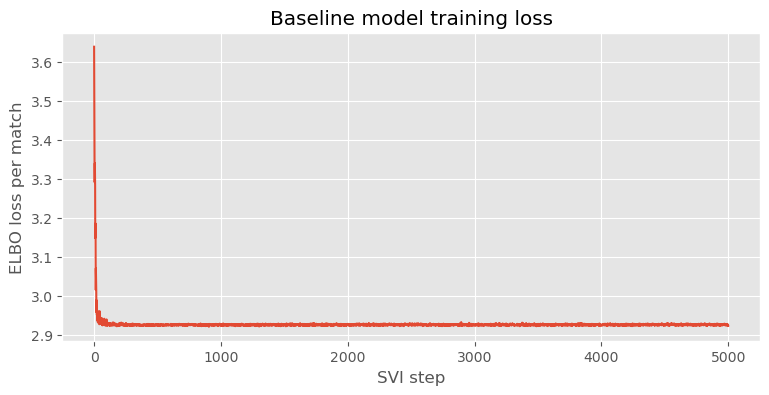

In [16]:
SEED = 42186
NUM_STEPS = 5000
LEARNING_RATE = 0.03

pyro.clear_param_store()
pyro.set_rng_seed(SEED)
torch.manual_seed(SEED)

model = FootballModel(n_teams=num_teams)
guide = AutoDiagonalNormal(model)
optimizer = Adam({"lr": LEARNING_RATE})
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

svi_losses = []
for step in range(NUM_STEPS):
    loss = svi.step(home_idx_train, away_idx_train, home_goals_train, away_goals_train)
    svi_losses.append(loss / len(train_df))
    if (step + 1) % 500 == 0:
        print(f"Step {step + 1:>5}/{NUM_STEPS} - loss per match: {svi_losses[-1]:.3f}")

assert np.isfinite(svi_losses).all(), "SVI produced non-finite losses."

plt.figure(figsize=(9, 4))
plt.plot(svi_losses)
plt.xlabel("SVI step")
plt.ylabel("ELBO loss per match")
plt.title("Baseline model training loss")
plt.show()


## 5. Posterior predictive match forecasts

We sample scorelines for the 2015/2016 second-half fixtures. The H/D/A probabilities are empirical frequencies across posterior predictive samples.


In [17]:
NUM_POSTERIOR_SAMPLES = 1000

predictive = Predictive(
    model,
    guide=guide,
    num_samples=NUM_POSTERIOR_SAMPLES,
    return_sites=("obs_home", "obs_away", "team_strengths", "home_adv"),
)
posterior_predictive = predictive(home_idx_second, away_idx_second)

home_goal_samples = posterior_predictive["obs_home"].detach().cpu().numpy()
away_goal_samples = posterior_predictive["obs_away"].detach().cpu().numpy()

assert home_goal_samples.shape == (NUM_POSTERIOR_SAMPLES, len(second_half_2015_df))
assert away_goal_samples.shape == (NUM_POSTERIOR_SAMPLES, len(second_half_2015_df))

home_win_prob = (home_goal_samples > away_goal_samples).mean(axis=0)
draw_prob = (home_goal_samples == away_goal_samples).mean(axis=0)
away_win_prob = (home_goal_samples < away_goal_samples).mean(axis=0)
prob_sums = home_win_prob + draw_prob + away_win_prob
assert np.allclose(prob_sums, 1.0), "H/D/A probabilities must sum to 1 for every match."

actual_result = np.select(
    [
        second_half_2015_df["home_team_goal"].to_numpy() > second_half_2015_df["away_team_goal"].to_numpy(),
        second_half_2015_df["home_team_goal"].to_numpy() == second_half_2015_df["away_team_goal"].to_numpy(),
    ],
    ["H", "D"],
    default="A",
)

prob_matrix = np.column_stack([home_win_prob, draw_prob, away_win_prob])
labels = np.array(["H", "D", "A"])
predicted_result = labels[prob_matrix.argmax(axis=1)]
actual_prob = np.array([
    {"H": h, "D": d, "A": a}[result]
    for result, h, d, a in zip(actual_result, home_win_prob, draw_prob, away_win_prob)
])

match_predictions_second_half = second_half_2015_df[
    ["season", "stage", "date", "home_team", "away_team", "home_team_goal", "away_team_goal"]
].copy()
match_predictions_second_half["actual_result"] = actual_result
match_predictions_second_half["predicted_home_goals_mean"] = home_goal_samples.mean(axis=0)
match_predictions_second_half["predicted_away_goals_mean"] = away_goal_samples.mean(axis=0)
match_predictions_second_half["home_win_prob"] = home_win_prob
match_predictions_second_half["draw_prob"] = draw_prob
match_predictions_second_half["away_win_prob"] = away_win_prob
match_predictions_second_half["predicted_result"] = predicted_result
match_predictions_second_half["actual_result_probability"] = actual_prob
match_predictions_second_half["correct_result"] = (
    match_predictions_second_half["actual_result"] == match_predictions_second_half["predicted_result"]
)

display(match_predictions_second_half.head(20))


,season,stage,date,home_team,away_team,home_team_goal,away_team_goal,actual_result,predicted_home_goals_mean,predicted_away_goals_mean,home_win_prob,draw_prob,away_win_prob,predicted_result,actual_result_probability,correct_result
2850,2015/2016,20,2016-01-02,Arsenal,Newcastle United,1,0,H,2.399,0.718,0.761,0.144,0.095,H,0.761,True
2851,2015/2016,20,2016-01-02,Leicester City,Bournemouth,0,0,D,2.074,0.818,0.681,0.182,0.137,H,0.182,False
2852,2015/2016,20,2016-01-02,Manchester United,Swansea City,2,1,H,2.269,0.737,0.712,0.191,0.097,H,0.712,True
2853,2015/2016,20,2016-01-02,Norwich City,Southampton,1,0,H,1.069,1.558,0.255,0.256,0.489,A,0.255,False
2854,2015/2016,20,2016-01-02,Sunderland,Aston Villa,3,1,H,1.439,1.219,0.428,0.262,0.310,H,0.428,True
2855,2015/2016,20,2016-01-02,Watford,Manchester City,1,2,A,1.209,1.419,0.331,0.247,0.422,A,0.422,True
2856,2015/2016,20,2016-01-02,West Bromwich Albion,Stoke City,2,1,H,1.443,1.157,0.431,0.259,0.310,H,0.431,True
2857,2015/2016,20,2016-01-02,West Ham United,Liverpool,2,0,H,1.118,1.586,0.275,0.251,0.474,A,0.275,False
2858,2015/2016,20,2016-01-03,Crystal Palace,Chelsea,0,3,A,1.065,1.546,0.241,0.268,0.491,A,0.491,True
2859,2015/2016,20,2016-01-03,Everton,Tottenham Hotspur,1,1,D,1.506,1.144,0.470,0.250,0.280,H,0.250,False


## 6. First-half table, actual final table, and simulations

The simulated final table starts from the actual first-half table and adds sampled second-half results. With all teams included, each team has 19 first-half matches and 38 full-season matches.


In [18]:
retained_2015_teams = sorted(set(season_2015_df["home_team"]).union(season_2015_df["away_team"]))
assert len(retained_2015_teams) == 20


def empty_table(teams):
    return {
        team: {
            "team": team,
            "played": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "goals_for": 0,
            "goals_against": 0,
            "goal_difference": 0,
            "points": 0,
        }
        for team in teams
    }


def add_result(table, home_team, away_team, home_goals, away_goals):
    home_goals = int(home_goals)
    away_goals = int(away_goals)

    table[home_team]["played"] += 1
    table[away_team]["played"] += 1
    table[home_team]["goals_for"] += home_goals
    table[home_team]["goals_against"] += away_goals
    table[away_team]["goals_for"] += away_goals
    table[away_team]["goals_against"] += home_goals

    if home_goals > away_goals:
        table[home_team]["wins"] += 1
        table[away_team]["losses"] += 1
        table[home_team]["points"] += 3
    elif home_goals == away_goals:
        table[home_team]["draws"] += 1
        table[away_team]["draws"] += 1
        table[home_team]["points"] += 1
        table[away_team]["points"] += 1
    else:
        table[away_team]["wins"] += 1
        table[home_team]["losses"] += 1
        table[away_team]["points"] += 3

    table[home_team]["goal_difference"] = table[home_team]["goals_for"] - table[home_team]["goals_against"]
    table[away_team]["goal_difference"] = table[away_team]["goals_for"] - table[away_team]["goals_against"]


def table_from_matches(matches_df, teams):
    table = empty_table(teams)
    for row in matches_df.itertuples(index=False):
        add_result(table, row.home_team, row.away_team, row.home_team_goal, row.away_team_goal)
    return rank_table(pd.DataFrame(table.values()))


def rank_table(table_df):
    table_df = table_df.copy()
    table_df = table_df.sort_values(
        ["points", "goal_difference", "goals_for", "team"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)
    table_df.insert(0, "rank", np.arange(1, len(table_df) + 1))
    return table_df


first_half_table = table_from_matches(first_half_2015_df, retained_2015_teams)
actual_final_table = table_from_matches(season_2015_df, retained_2015_teams)

assert (first_half_table["played"] == 19).all(), "Each team should have 19 first-half matches."
assert (actual_final_table["played"] == 38).all(), "Each team should have 38 full-season matches."

display(first_half_table)
display(actual_final_table)


,rank,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
0,1,Arsenal,19,12,3,4,33,18,15,39
1,2,Leicester City,19,11,6,2,37,25,12,39
2,3,Manchester City,19,11,3,5,37,20,17,36
3,4,Tottenham Hotspur,19,9,8,2,33,15,18,35
4,5,Crystal Palace,19,9,4,6,23,16,7,31
5,6,Manchester United,19,8,6,5,22,16,6,30
6,7,Liverpool,19,8,6,5,22,22,0,30
7,8,West Ham United,19,7,8,4,28,23,5,29
8,9,Watford,19,8,5,6,24,20,4,29
9,10,Stoke City,19,8,5,6,20,19,1,29


,rank,team,played,wins,draws,losses,goals_for,goals_against,goal_difference,points
0,1,Leicester City,38,23,12,3,68,36,32,81
1,2,Arsenal,38,20,11,7,65,36,29,71
2,3,Tottenham Hotspur,38,19,13,6,69,35,34,70
3,4,Manchester City,38,19,9,10,71,41,30,66
4,5,Manchester United,38,19,9,10,49,35,14,66
5,6,Southampton,38,18,9,11,59,41,18,63
6,7,West Ham United,38,16,14,8,65,51,14,62
7,8,Liverpool,38,16,12,10,63,50,13,60
8,9,Stoke City,38,14,9,15,41,55,-14,51
9,10,Chelsea,38,12,14,12,59,53,6,50


In [19]:
simulated_table_rows = []

for sample_id in range(NUM_POSTERIOR_SAMPLES):
    table = empty_table(retained_2015_teams)

    for row in first_half_2015_df.itertuples(index=False):
        add_result(table, row.home_team, row.away_team, row.home_team_goal, row.away_team_goal)

    for match_idx, row in enumerate(second_half_2015_df.itertuples(index=False)):
        add_result(
            table,
            row.home_team,
            row.away_team,
            home_goal_samples[sample_id, match_idx],
            away_goal_samples[sample_id, match_idx],
        )

    sample_table = rank_table(pd.DataFrame(table.values()))
    assert (sample_table["played"] == 38).all(), "Every simulated team should have 38 matches."
    sample_table["sample_id"] = sample_id
    simulated_table_rows.append(sample_table)

simulated_tables = pd.concat(simulated_table_rows, ignore_index=True)

predicted_final_table = (
    simulated_tables.groupby("team")
    .agg(
        expected_points=("points", "mean"),
        points_p05=("points", lambda x: np.quantile(x, 0.05)),
        points_p95=("points", lambda x: np.quantile(x, 0.95)),
        expected_goal_difference=("goal_difference", "mean"),
        mean_rank=("rank", "mean"),
        rank_p05=("rank", lambda x: np.quantile(x, 0.05)),
        rank_p95=("rank", lambda x: np.quantile(x, 0.95)),
        title_probability=("rank", lambda x: np.mean(x == 1)),
        top4_probability=("rank", lambda x: np.mean(x <= 4)),
    )
    .reset_index()
)

predicted_final_table = predicted_final_table.merge(
    actual_final_table[["team", "rank", "points", "goal_difference"]].rename(
        columns={
            "rank": "actual_rank",
            "points": "actual_points",
            "goal_difference": "actual_goal_difference",
        }
    ),
    on="team",
    how="left",
)

predicted_final_table["points_error"] = (
    predicted_final_table["expected_points"] - predicted_final_table["actual_points"]
)
predicted_final_table["rank_error"] = (
    predicted_final_table["mean_rank"] - predicted_final_table["actual_rank"]
)
predicted_final_table = predicted_final_table.sort_values(
    ["expected_points", "expected_goal_difference", "team"],
    ascending=[False, False, True],
).reset_index(drop=True)
predicted_final_table.insert(0, "predicted_rank", np.arange(1, len(predicted_final_table) + 1))

display(predicted_final_table)


,predicted_rank,team,expected_points,points_p05,points_p95,expected_goal_difference,mean_rank,rank_p05,rank_p95,title_probability,top4_probability,actual_rank,actual_points,actual_goal_difference,points_error,rank_error
0,1,Arsenal,73.968,65.95,83.00,28.638,2.133,1.0,5.00,0.451,0.934,2,71,29,2.968,0.133
1,2,Manchester City,72.202,63.00,81.00,32.818,2.441,1.0,5.00,0.313,0.890,4,66,30,6.202,-1.559
2,3,Manchester United,67.714,58.95,76.00,24.197,3.883,1.0,8.00,0.095,0.686,5,66,14,1.714,-1.117
3,4,Leicester City,66.734,57.00,77.00,14.143,4.467,1.0,9.00,0.080,0.548,1,81,32,-14.266,3.467
4,5,Tottenham Hotspur,64.097,55.00,74.00,22.435,5.217,2.0,9.00,0.034,0.421,3,70,34,-5.903,2.217
5,6,Liverpool,62.478,52.00,72.00,9.861,6.118,2.0,11.00,0.020,0.269,8,60,13,2.478,-1.882
6,7,Chelsea,57.245,48.00,67.00,11.408,8.192,4.0,12.00,0.000,0.069,10,50,6,7.245,-1.808
7,8,Watford,57.220,46.00,68.00,7.147,8.337,3.0,13.00,0.006,0.098,13,45,-10,12.220,-4.663
8,9,Crystal Palace,54.769,46.00,64.00,3.197,9.497,5.0,14.00,0.001,0.028,15,42,-12,12.769,-5.503
9,10,Everton,54.632,45.00,63.05,10.850,9.370,5.0,13.00,0.000,0.030,11,47,4,7.632,-1.630


## 7. Visualizing inferred strengths and forecast quality

The next plots summarize what the baseline model learned and how its mid-season forecast compares with the actual 2015/2016 outcome.


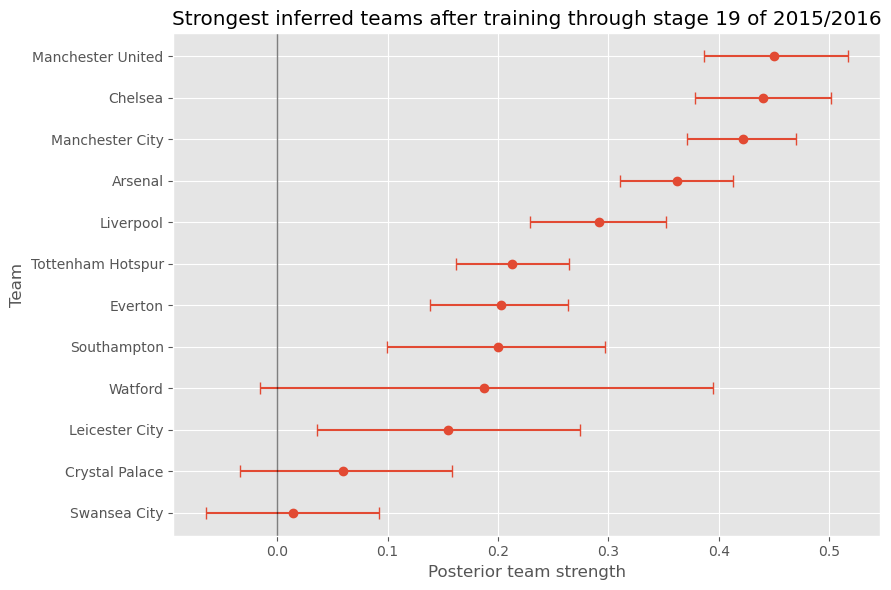

,team,strength_mean,strength_p05,strength_p95
17,Manchester United,0.450330,0.386594,0.517057
9,Chelsea,0.439739,0.378956,0.501821
16,Manchester City,0.421748,0.371215,0.469753
0,Arsenal,0.361910,0.310780,0.413034
15,Liverpool,0.291190,0.228853,0.352593
28,Tottenham Hotspur,0.212488,0.161610,0.263889
11,Everton,0.202304,0.138466,0.263228
24,Southampton,0.199707,0.099408,0.296522
29,Watford,0.187364,-0.015751,0.395132
14,Leicester City,0.154991,0.035767,0.274470


In [20]:
# Plot the strongest teams according to the inferred latent team-strength posterior.
team_strength_samples = posterior_predictive["team_strengths"].detach().cpu().numpy()

team_strength_summary = pd.DataFrame(
    {
        "team": [idx_to_team[idx] for idx in range(num_teams)],
        "strength_mean": team_strength_samples.mean(axis=0),
        "strength_p05": np.quantile(team_strength_samples, 0.05, axis=0),
        "strength_p95": np.quantile(team_strength_samples, 0.95, axis=0),
    }
).sort_values("strength_mean", ascending=False)

top_strengths = team_strength_summary.head(12).sort_values("strength_mean")

plt.figure(figsize=(9, 6))
plt.errorbar(
    top_strengths["strength_mean"],
    top_strengths["team"],
    xerr=[
        top_strengths["strength_mean"] - top_strengths["strength_p05"],
        top_strengths["strength_p95"] - top_strengths["strength_mean"],
    ],
    fmt="o",
    capsize=4,
)
plt.axvline(0, color="black", linewidth=1, alpha=0.5)
plt.xlabel("Posterior team strength")
plt.ylabel("Team")
plt.title("Strongest inferred teams after training through stage 19 of 2015/2016")
plt.tight_layout()
plt.show()

display(team_strength_summary.head(12))


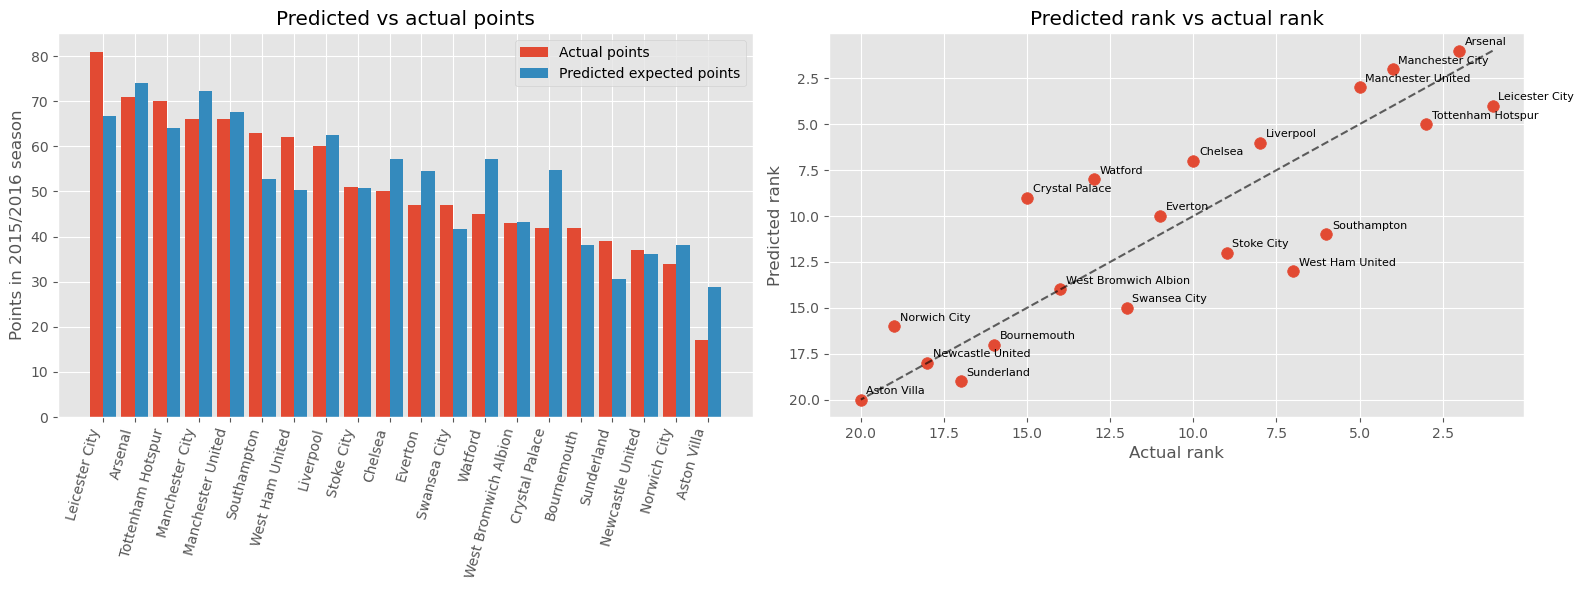

,team,actual_rank,predicted_rank,actual_points,expected_points,points_error,rank_error
3,Leicester City,1,4,81,66.734,-14.266,3.467
0,Arsenal,2,1,71,73.968,2.968,0.133
4,Tottenham Hotspur,3,5,70,64.097,-5.903,2.217
1,Manchester City,4,2,66,72.202,6.202,-1.559
2,Manchester United,5,3,66,67.714,1.714,-1.117
10,Southampton,6,11,63,52.760,-10.240,4.297
12,West Ham United,7,13,62,50.359,-11.641,4.489
5,Liverpool,8,6,60,62.478,2.478,-1.882
11,Stoke City,9,12,51,50.790,-0.210,2.397
6,Chelsea,10,7,50,57.245,7.245,-1.808


In [21]:
# Plot predicted final outcome against the actual retained 2015/2016 outcome.
comparison_table = predicted_final_table.sort_values("actual_rank").copy()
comparison_table["team_label"] = comparison_table["team"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(comparison_table))
bar_width = 0.42
axes[0].bar(
    x - bar_width / 2,
    comparison_table["actual_points"],
    width=bar_width,
    label="Actual points",
)
axes[0].bar(
    x + bar_width / 2,
    comparison_table["expected_points"],
    width=bar_width,
    label="Predicted expected points",
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_table["team_label"], rotation=75, ha="right")
axes[0].set_ylabel("Points in 2015/2016 season")
axes[0].set_title("Predicted vs actual points")
axes[0].legend()

axes[1].scatter(
    comparison_table["actual_rank"],
    comparison_table["predicted_rank"],
    s=70,
)
for row in comparison_table.itertuples(index=False):
    axes[1].annotate(
        row.team,
        (row.actual_rank, row.predicted_rank),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
    )
max_rank = len(comparison_table)
axes[1].plot([1, max_rank], [1, max_rank], linestyle="--", color="black", alpha=0.6)
axes[1].invert_xaxis()
axes[1].invert_yaxis()
axes[1].set_xlabel("Actual rank")
axes[1].set_ylabel("Predicted rank")
axes[1].set_title("Predicted rank vs actual rank")

plt.tight_layout()
plt.show()

display(
    comparison_table[
        [
            "team",
            "actual_rank",
            "predicted_rank",
            "actual_points",
            "expected_points",
            "points_error",
            "rank_error",
        ]
    ]
)


## 8. Evaluation



In [22]:
EPS = 1e-12
second_half_accuracy = match_predictions_second_half["correct_result"].mean()
second_half_nll = -np.log(np.clip(match_predictions_second_half["actual_result_probability"], EPS, 1.0)).mean()

table_mae_points = predicted_final_table["points_error"].abs().mean()
table_mae_rank = predicted_final_table["rank_error"].abs().mean()

evaluation_summary = pd.DataFrame(
    [
        {"metric": "second_half_result_accuracy", "value": second_half_accuracy},
        {"metric": "second_half_hda_negative_log_likelihood", "value": second_half_nll},
        {"metric": "final_table_points_mae", "value": table_mae_points},
        {"metric": "final_table_rank_mae", "value": table_mae_rank},
        {"metric": "forecast_matches", "value": len(second_half_2015_df)},
        {"metric": "retained_teams", "value": len(retained_2015_teams)},
    ]
)

display(evaluation_summary)
display(
    match_predictions_second_half[
        [
            "stage",
            "date",
            "home_team",
            "away_team",
            "home_team_goal",
            "away_team_goal",
            "actual_result",
            "predicted_result",
            "home_win_prob",
            "draw_prob",
            "away_win_prob",
            "correct_result",
        ]
    ].head(30)
)


,metric,value
0,second_half_result_accuracy,0.494737
1,second_half_hda_negative_log_likelihood,1.042190
2,final_table_points_mae,6.510850
3,final_table_rank_mae,2.262600
4,forecast_matches,190.000000
5,retained_teams,20.000000


,stage,date,home_team,away_team,home_team_goal,away_team_goal,actual_result,predicted_result,home_win_prob,draw_prob,away_win_prob,correct_result
2850,20,2016-01-02,Arsenal,Newcastle United,1,0,H,H,0.761,0.144,0.095,True
2851,20,2016-01-02,Leicester City,Bournemouth,0,0,D,H,0.681,0.182,0.137,False
2852,20,2016-01-02,Manchester United,Swansea City,2,1,H,H,0.712,0.191,0.097,True
2853,20,2016-01-02,Norwich City,Southampton,1,0,H,A,0.255,0.256,0.489,False
2854,20,2016-01-02,Sunderland,Aston Villa,3,1,H,H,0.428,0.262,0.310,True
2855,20,2016-01-02,Watford,Manchester City,1,2,A,A,0.331,0.247,0.422,True
2856,20,2016-01-02,West Bromwich Albion,Stoke City,2,1,H,H,0.431,0.259,0.310,True
2857,20,2016-01-02,West Ham United,Liverpool,2,0,H,A,0.275,0.251,0.474,False
2858,20,2016-01-03,Crystal Palace,Chelsea,0,3,A,A,0.241,0.268,0.491,True
2859,20,2016-01-03,Everton,Tottenham Hotspur,1,1,D,H,0.470,0.250,0.280,False


## 9. Result analysis

This cell turns the numerical outputs into a short interpretation. Because it reads from the fitted model outputs above, rerunning the model will automatically update the analysis.


In [23]:
from IPython.display import Markdown, display


def metric_value(metric_name):
    value = evaluation_summary.loc[
        evaluation_summary["metric"] == metric_name,
        "value",
    ].iloc[0]
    return float(value)


accuracy = metric_value("second_half_result_accuracy")
nll = metric_value("second_half_hda_negative_log_likelihood")
points_mae = metric_value("final_table_points_mae")
rank_mae = metric_value("final_table_rank_mae")

top_strength = team_strength_summary.head(5).copy()
top_expected = predicted_final_table.head(5).copy()
largest_overprediction = predicted_final_table.sort_values("points_error", ascending=False).head(3)
largest_underprediction = predicted_final_table.sort_values("points_error", ascending=True).head(3)
largest_rank_misses = (
    predicted_final_table.assign(abs_rank_error=predicted_final_table["rank_error"].abs())
    .sort_values("abs_rank_error", ascending=False)
    .head(3)
)

winner_row = predicted_final_table.iloc[0]
actual_winner_row = actual_final_table.iloc[0]

analysis_text = f'''
### Baseline model interpretation

The baseline model predicts the 2015/2016 second half with an H/D/A accuracy of **{accuracy:.1%}** and an average H/D/A negative log likelihood of **{nll:.3f}**. Since the model only knows team strength and home advantage, this is best interpreted as a simple probabilistic benchmark rather than a fully informed football forecasting model.

The strongest inferred teams after training through stage 19 are **{", ".join(top_strength["team"].tolist())}**. These strengths summarize long-run scoring performance in the training data, including the first half of the target season.

The model's most likely final-season winner is **{winner_row["team"]}** with **{winner_row["expected_points"]:.1f}** expected points. The actual winner is **{actual_winner_row["team"]}** with **{actual_winner_row["points"]:.0f}** points.

Across the full 20-team final table, the mean absolute points error is **{points_mae:.2f}** and the mean absolute rank error is **{rank_mae:.2f}** positions. This gives a compact measure of how well the model turns mid-season information into a final-table forecast.

The biggest points over-predictions are **{", ".join(largest_overprediction["team"].tolist())}**. The biggest points under-predictions are **{", ".join(largest_underprediction["team"].tolist())}**. The largest rank misses are **{", ".join(largest_rank_misses["team"].tolist())}**.

Overall, this baseline is useful for the report because its mistakes are interpretable: it can learn broad team quality and home advantage, but it cannot capture player availability, tactical changes, betting-market information, team-specific attack/defense balance, or time-varying form.
'''

display(Markdown(analysis_text))

display(
    top_expected[
        [
            "predicted_rank",
            "team",
            "expected_points",
            "actual_rank",
            "actual_points",
            "points_error",
            "rank_error",
            "title_probability",
            "top4_probability",
        ]
    ]
)



### Baseline model interpretation

The baseline model predicts the 2015/2016 second half with an H/D/A accuracy of **49.5%** and an average H/D/A negative log likelihood of **1.042**. Since the model only knows team strength and home advantage, this is best interpreted as a simple probabilistic benchmark rather than a fully informed football forecasting model.

The strongest inferred teams after training through stage 19 are **Manchester United, Chelsea, Manchester City, Arsenal, Liverpool**. These strengths summarize long-run scoring performance in the training data, including the first half of the target season.

The model's most likely final-season winner is **Arsenal** with **74.0** expected points. The actual winner is **Leicester City** with **81** points.

Across the full 20-team final table, the mean absolute points error is **6.51** and the mean absolute rank error is **2.26** positions. This gives a compact measure of how well the model turns mid-season information into a final-table forecast.

The biggest points over-predictions are **Crystal Palace, Watford, Aston Villa**. The biggest points under-predictions are **Leicester City, West Ham United, Southampton**. The largest rank misses are **Crystal Palace, Watford, West Ham United**.

Overall, this baseline is useful for the report because its mistakes are interpretable: it can learn broad team quality and home advantage, but it cannot capture player availability, tactical changes, betting-market information, team-specific attack/defense balance, or time-varying form.


,predicted_rank,team,expected_points,actual_rank,actual_points,points_error,rank_error,title_probability,top4_probability
0,1,Arsenal,73.968,2,71,2.968,0.133,0.451,0.934
1,2,Manchester City,72.202,4,66,6.202,-1.559,0.313,0.890
2,3,Manchester United,67.714,5,66,1.714,-1.117,0.095,0.686
3,4,Leicester City,66.734,1,81,-14.266,3.467,0.080,0.548
4,5,Tottenham Hotspur,64.097,3,70,-5.903,2.217,0.034,0.421


## 10. Export results

The exports below are optional project artifacts. They contain the second-half match forecasts and the mid-season table forecast with all 20 teams included.


In [24]:
match_predictions_path = DATA_DIR / "epl_2015_second_half_predictions.csv"
predicted_table_path = DATA_DIR / "epl_2015_midseason_predicted_table.csv"

match_predictions_second_half.to_csv(match_predictions_path, index=False)
predicted_final_table.to_csv(predicted_table_path, index=False)

print(f"Saved match predictions to: {match_predictions_path}")
print(f"Saved predicted final table to: {predicted_table_path}")


Saved match predictions to: C:\Users\Madsl\Dropbox\DTU\Kand\3.Semester\MBML\Project_MBML\data\epl_2015_second_half_predictions.csv
Saved predicted final table to: C:\Users\Madsl\Dropbox\DTU\Kand\3.Semester\MBML\Project_MBML\data\epl_2015_midseason_predicted_table.csv


## 11. Interpretation notes

This baseline is useful because it is transparent: all predictions flow through latent team strengths and home advantage. It is also intentionally limited. The model does not use player attributes, betting odds, injuries, time-varying form, separate attack/defense strengths, or any explicit promotion/relegation mechanism.

Bournemouth and Watford are included in this version. Their estimated strengths are informed by the first half of 2015/2016, so the second-half forecast does not rely on prior-only predictions for newly promoted teams.
